# Configuration

In [1]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import gc
torch.set_num_threads(1)
torch.set_num_interop_threads(1)

In [2]:
# Set up Random SEED
SEED = 100
np.random.seed(SEED)
torch.manual_seed(SEED)

# Load Stock Data

In [3]:
# Load dataset from a specific TICKER
TICKER = "AAPL"
X_raw = pd.read_csv(f"../data/selected/{TICKER}_X.csv")
y_raw = pd.read_csv(f"../data/selected/{TICKER}_y.csv")

In [4]:
dates = pd.to_datetime(X_raw["date"])
X = X_raw.drop(columns="date").values
y = np.ravel(y_raw.values)

# Create Time Series Split for CV

In [5]:
'''
Generates training and testing indices on each time-series-split data

Args:
    data: dataset (or feature matrix) of a stock to split.
    n_splits: Number of folds.
    test_size: Size of each test set.
    gap: Number of samples to exclude between train and test.

Returns:
    List of dicts with keys: (1) "fold": fold number, 0-based (2) "train_idx": training indices (3) "test_idx": testing indices
'''
def createTimeSeriesSplit(data, n_splits = 5, test_size = 90, gap = 50):
    tss = TimeSeriesSplit(n_splits = n_splits, test_size = test_size, gap = gap)

    folds = [] 
    for k, (train_idx, test_idx) in enumerate(tss.split(data)): #enum to add k folds 
        folds.append({
            "fold": k,
            "train_idx": train_idx,  
            "test_idx": test_idx,
        })
    return folds

In [6]:
TICKER = 'TSLA'
folds = createTimeSeriesSplit(data=X)
# folds

# XGBoost

In [7]:
'''
Perform Time-Series CV on a XGBoost model
Args: 
    base_params: the base parameters of the xgboost model
    folds: created from time series split
    ticker: a stock symbol (e.g, TSLA)
    X: a numpy ndarray feature matrix (shape: [n_samples, n_features])
    y: a numpy 1d array target vector (shape: [n_features])
    dates: a pandas series containing all the datetimes
Returns: 
    model predictions, actual results, and rmse scores on each time-series-split test set (there is a list of them)
'''
def train_xgb(base_params=None, folds=None, ticker=None, X=None, y=None, dates=None):

    # Use default one if user did not provide hyperparameters (FEEL FREE TO ADD MORE!)
    if not base_params:
        base_params = {"n_estimators": 1000, "early_stopping_rounds": 50, 
                       "max_depth": 6, "random_state":SEED, "objective":'reg:squarederror'}

    preds, tests = [], []
    scores = []
    
    for fold in folds:
        train_idx, test_idx = fold["train_idx"], fold["test_idx"]
        X_train, y_train = X[train_idx], y[train_idx]
        X_test, y_test = X[test_idx], y[test_idx]
            
        reg = xgb.XGBRegressor(**base_params)
        reg.fit(X_train, y_train, eval_set=[(X_train,y_train), (X_test, y_test)], verbose=100)
        
        y_pred = reg.predict(X_test)
        
        tests.append(pd.Series(y_test, index=dates[test_idx]))
        preds.append(pd.Series(y_pred, index=dates[test_idx]))
        score = root_mean_squared_error(y_test, y_pred)
        scores.append(score)

    return preds, tests, scores

In [8]:
preds_xgb, tests_xgb, scores_xgb = train_xgb(folds=folds, ticker='TSLA', X=X, y=y, dates=dates)
print(f"CV Error: {np.mean(scores_xgb):.4f}")

[0]	validation_0-rmse:0.01870	validation_1-rmse:0.01210
[56]	validation_0-rmse:0.00461	validation_1-rmse:0.01412
[0]	validation_0-rmse:0.01837	validation_1-rmse:0.01721
[70]	validation_0-rmse:0.00348	validation_1-rmse:0.01740
[0]	validation_0-rmse:0.01810	validation_1-rmse:0.01155
[49]	validation_0-rmse:0.00576	validation_1-rmse:0.01499
[0]	validation_0-rmse:0.01804	validation_1-rmse:0.02790
[50]	validation_0-rmse:0.00564	validation_1-rmse:0.03253
[0]	validation_0-rmse:0.01790	validation_1-rmse:0.01531
[51]	validation_0-rmse:0.00625	validation_1-rmse:0.01649
CV Error: 0.0166


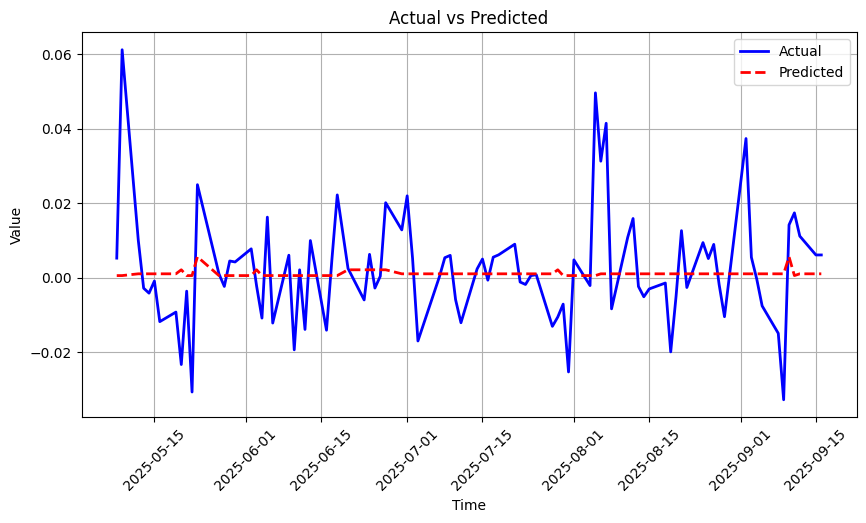

In [9]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests_xgb[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds_xgb[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# LSTM

In [10]:
# Class Definition
class LSTMRegressor(nn.Module):
    def __init__(self, base_params=None):
        super(LSTMRegressor, self).__init__()
        # Default hyperparameters
        defaults = {
            "input_dimension": X.shape[1],
            "hidden_dimension": 16,
            "layer_dimension": 2,
            "output_dimension": 1,
            "dropout": 0.1,
            "lr": 1e-3,
            "num_epochs": 10, # number of forward passes
            "seq_len": 3, # how far back in time the model “looks” when making a prediction
        }
        
        # Merge user-supplied params with defaults
        if base_params is not None:
            defaults.update(base_params)
        self.params = defaults

        # Extract for convenience
        input_dim  = self.params["input_dimension"]
        hidden_dim = self.params["hidden_dimension"]
        num_layers = self.params["layer_dimension"]
        output_dim = self.params["output_dimension"]
        dropout    = self.params["dropout"]

        # --- Define LSTM layers ---
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x, h0=None, c0=None):
        """
        x: (B, L, F)
        """
        if h0 is None or c0 is None:
            h0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])
            c0 = torch.zeros(self.params["layer_dimension"], x.size(0), self.params["hidden_dimension"])

        out, _ = self.lstm(x, (h0, c0))     # out: (B, L, H)
        out = self.fc(out[:, -1, :])        # use last timestep
        return out.squeeze(-1)

In [11]:
"""
Perform Time-Series CV on an LSTM model (same interface/returns as train_xgb).

Args:
	base_params: dict of hyperparameters for LSTMRegressor (e.g. {'seq_len':60,'num_epochs':20,'lr':1e-3})
	folds: list of dicts with 'train_idx' and 'test_idx' (from time series split)
	ticker: stock symbol key for feature_matrices
	X: a numpy ndarray feature matrix (shape: [n_samples, n_features])
	y: a numpy 1d array target vector (shape: [n_samples])
	dates: a pandas series containing all the datetimes

Returns:
	preds:  list[pd.Series]  predicted values on each test fold (indexed by test dates)
	tests:  list[pd.Series]  ground-truth values on each test fold (indexed by test dates)
	scores: list[float]      RMSE per fold
"""


def train_lstm(base_params=None, folds=None, ticker=None, X=None, y=None, dates=None):
	# --- Default values if base_params are not specified ---
	defaults = {"seq_len": 5, "num_epochs": 20, "lr": 1e-3}
	params = {**defaults, **(base_params or {})}
	L = int(params["seq_len"])
	epochs = int(params["num_epochs"])
	lr = float(params["lr"])

	# ---- Validate & coerce inputs ----
	assert X is not None and y is not None and dates is not None, "X, y, and dates must be provided"
	X_np = np.asarray(X, dtype=np.float32)
	y_np = np.asarray(y, dtype=np.float32).reshape(-1)
	dates_all = pd.to_datetime(pd.Series(dates))

	assert X_np.ndim == 2, "X must be 2D: [n_samples, n_features]"
	assert y_np.ndim == 1, "y must be 1D: [n_samples]"
	assert len(X_np) == len(y_np) == len(dates_all), "Length mismatch among X, y, dates"

	preds, tests, scores = [], [], []

	for fold in folds:
		train_idx, test_idx = fold["train_idx"], fold["test_idx"]

		X_train_full, y_train_full = X_np[train_idx], y_np[train_idx]
		X_test_full,  y_test_full  = X_np[test_idx],  y_np[test_idx]
		dates_test = dates_all.iloc[test_idx]

		# Skip too-short folds
		if len(X_train_full) <= L or len(X_test_full) <= L:
			preds.append(pd.Series(dtype="float32"))
			tests.append(pd.Series(dtype="float32"))
			scores.append(np.nan)
			continue

		# --- Initialize model/optim/criterion ---
		model = LSTMRegressor(params)
		criterion = nn.MSELoss()
		optimizer = torch.optim.Adam(model.parameters(), lr=lr)

		# --- Training loop (windowed, single-step ahead) ---
		model.train()
		for epoch in range(epochs):
			total_loss = 0.0
			for i in range(len(X_train_full) - L):
				x_seq = torch.as_tensor(X_train_full[i:i + L], dtype=torch.float32).unsqueeze(0)  # [1, L, D]
				y_t = torch.as_tensor([y_train_full[i + L]], dtype=torch.float32)                 # [1]

				optimizer.zero_grad(set_to_none=True)
				y_pred = model(x_seq).view(-1)
				loss = criterion(y_pred, y_t)
				loss.backward()
				optimizer.step()
				total_loss += float(loss.detach())

			if (epoch + 1) % 5 == 0:
				avg = total_loss / max(len(X_train_full) - L, 1)
				print(f"[Fold {fold.get('fold','?')}] Epoch {epoch + 1} | Train RMSE: {avg ** 0.5:.4f}")

		# --- Inference on test fold (same windowing) ---
		model.eval()
		preds_fold = []
		with torch.no_grad():
			for i in range(len(X_test_full) - L):
				x_seq = torch.as_tensor(X_test_full[i:i + L], dtype=torch.float32).unsqueeze(0)
				y_hat = model(x_seq).view(-1)[0].item()
				preds_fold.append(y_hat)

		# Align to dates (drop first L points because of the window)
		idx = pd.to_datetime(dates_test)[L:]
		y_test_seq = y_test_full[L:]
		y_pred_seq = np.asarray(preds_fold, dtype=np.float32)[:len(y_test_seq)]

		y_test_series = pd.Series(y_test_seq, index=idx)
		y_pred_series = pd.Series(y_pred_seq, index=idx)

		rmse = float(np.sqrt(np.mean((y_pred_series.values - y_test_series.values) ** 2)))
		print(f"[Fold {fold.get('fold','?')}] | Test RMSE: {rmse:.4f}")

		tests.append(y_test_series)
		preds.append(y_pred_series)
		scores.append(rmse)

		gc.collect()

	return preds, tests, scores

In [12]:
preds_lstm, tests_lstm, scores_lstm = train_lstm(folds=folds, ticker='TSLA', X=X, y=y, dates=dates)
print(f"CV Error: {np.mean(scores_lstm):.4f}")

[Fold 0] Epoch 5 | Train RMSE: 0.0201
[Fold 0] Epoch 10 | Train RMSE: 0.0196
[Fold 0] Epoch 15 | Train RMSE: 0.0192
[Fold 0] Epoch 20 | Train RMSE: 0.0186
[Fold 0] | Test RMSE: 0.0131
[Fold 1] Epoch 5 | Train RMSE: 0.0197
[Fold 1] Epoch 10 | Train RMSE: 0.0192
[Fold 1] Epoch 15 | Train RMSE: 0.0186
[Fold 1] Epoch 20 | Train RMSE: 0.0180
[Fold 1] | Test RMSE: 0.0198
[Fold 2] Epoch 5 | Train RMSE: 0.0193
[Fold 2] Epoch 10 | Train RMSE: 0.0189
[Fold 2] Epoch 15 | Train RMSE: 0.0185
[Fold 2] Epoch 20 | Train RMSE: 0.0179
[Fold 2] | Test RMSE: 0.0135
[Fold 3] Epoch 5 | Train RMSE: 0.0193
[Fold 3] Epoch 10 | Train RMSE: 0.0189
[Fold 3] Epoch 15 | Train RMSE: 0.0183
[Fold 3] Epoch 20 | Train RMSE: 0.0175
[Fold 3] | Test RMSE: 0.0315
[Fold 4] Epoch 5 | Train RMSE: 0.0191
[Fold 4] Epoch 10 | Train RMSE: 0.0187
[Fold 4] Epoch 15 | Train RMSE: 0.0183
[Fold 4] Epoch 20 | Train RMSE: 0.0175
[Fold 4] | Test RMSE: 0.0170
CV Error: 0.0190


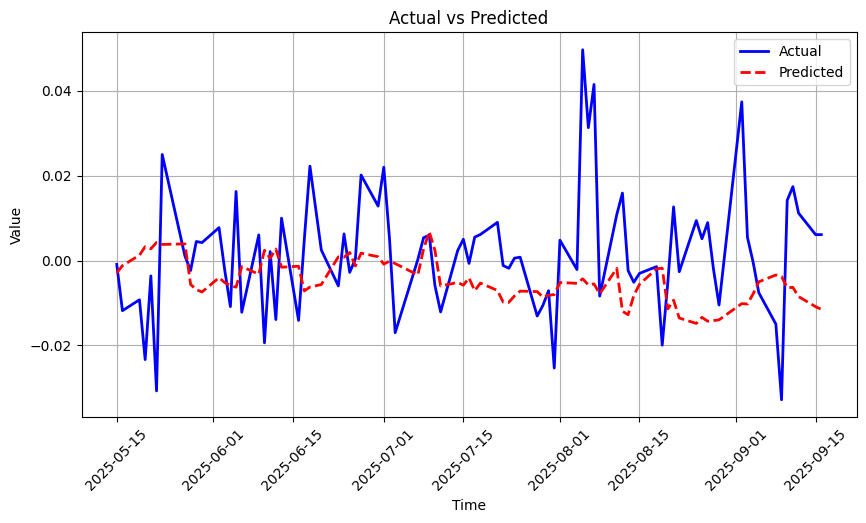

In [13]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests_lstm[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds_lstm[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()